In [1]:
# Cell 1 — Check GPU
import torch, os, sys
print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
# Cell 2 — Install dependencies
import sys

!{sys.executable} -m pip -q install --upgrade pip
!{sys.executable} -m pip -q install opencv-python-headless pyyaml matplotlib pandas transformers accelerate timm huggingface_hub

print("Install complete. If DINO import fails, restart runtime once and rerun from Cell 1.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 52.1 MB/s eta 0:00:00
Install complete. If DINO import fails, restart runtime once and rerun from Cell 1.


In [3]:
# Cell 3 — Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Cell 4 — Configuration
from pathlib import Path

try:
    from google.colab import userdata
    from huggingface_hub import login
    hf_token = userdata.get("HF_TOKEN")
    if hf_token:
        login(token=hf_token)
except Exception as e:
    print("HF login skipped:", e)

VIDEO_DIR = Path('/content/drive/MyDrive/CS591 Digital Image Processing/Videos')
OUTPUT_DIR = Path('/content/poster_flyer_rcnn_dataset')

TARGET_COUNT = 100
SAMPLE_EVERY = 15
MIN_MOTION = 8.0
MIN_SHARPNESS = 60.0
MAX_WIDTH = 1280
DINO_MODEL_ID = 'IDEA-Research/grounding-dino-tiny'
DINO_TEXT_PROMPT = 'poster. flyer.'
DINO_BOX_THRESHOLD = 0.25
DINO_TEXT_THRESHOLD = 0.25
DINO_CONTAINMENT_THRESHOLD = 0.90
DINO_MIN_PARENT_CHILD_AREA_RATIO = 1.15
DINO_MAX_PARENT_CHILD_AREA_RATIO = 20.0
DINO_MIN_TOTAL_CHILD_AREA_FRAC = 0.10
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
SEED = 42

EPOCHS = 25
IMG_SIZE = 640
BATCH = 2
WORKERS = 0
LR = 0.0005
WEIGHT_DECAY = 0.0005
PROJECT = '/content/runs_faster_rcnn'
RUN_NAME = 'poster_flyer_finetune'
CLASS_NAME = 'poster_flyer'
INFER_CONF = 0.25

VIDEO_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('VIDEO_DIR:', VIDEO_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


VIDEO_DIR: /content/drive/MyDrive/CS591 Digital Image Processing/Videos
OUTPUT_DIR: /content/poster_flyer_rcnn_dataset


In [5]:
# Cell 5 — Find input videos
VIDEO_EXTS = {'.mp4', '.mov', '.avi', '.mkv', '.m4v', '.webm'}
video_paths = sorted([p for p in VIDEO_DIR.rglob('*') if p.suffix.lower() in VIDEO_EXTS])

print(f'Found {len(video_paths)} video(s):')
for p in video_paths:
    print(' -', p)

assert len(video_paths) > 0, f'No videos found in {VIDEO_DIR}. Upload videos or change VIDEO_DIR.'


Found 7 video(s):
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260420_114406.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260420_114525.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260420_114740.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260422_060000.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260422_060400.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260422_060700.mp4
 - /content/drive/MyDrive/CS591 Digital Image Processing/Videos/20260422_061400.mp4


In [6]:
# Cell 6 — Dataset generation code: videos → frames → DINO boxes → Faster R-CNN annotations
import os
import cv2
import json
import shutil
import random
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection


def laplacian_sharpness(frame_bgr):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def frame_difference_score(frame_a, frame_b, resize_width=320):
    if frame_a is None or frame_b is None:
        return float('inf')

    def resize(frame):
        h, w = frame.shape[:2]
        scale = resize_width / w
        return cv2.resize(frame, (resize_width, int(h * scale)))

    a = resize(frame_a)
    b = resize(frame_b)

    if a.shape != b.shape:
        b = cv2.resize(b, (a.shape[1], a.shape[0]))

    return float(np.mean(cv2.absdiff(a, b)))


def box_area(box):
    x1, y1, x2, y2 = [float(v) for v in box]
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)


def intersection_area(a, b):
    ax1, ay1, ax2, ay2 = [float(v) for v in a]
    bx1, by1, bx2, by2 = [float(v) for v in b]
    x1 = max(ax1, bx1)
    y1 = max(ay1, by1)
    x2 = min(ax2, bx2)
    y2 = min(ay2, by2)
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)


def filter_containing_boxes(
    boxes,
    containment_threshold=0.90,
    min_parent_child_area_ratio=1.15,
    max_parent_child_area_ratio=20.0,
    min_total_child_area_frac=0.10,
):
    boxes = [[float(v) for v in box] for box in boxes]
    if len(boxes) <= 1:
        return boxes, 0

    areas = [box_area(box) for box in boxes]
    remove = set()

    for i, parent in enumerate(boxes):
        parent_area = areas[i]
        if parent_area <= 0:
            remove.add(i)
            continue

        child_area_sum = 0.0
        child_count = 0

        for j, child in enumerate(boxes):
            if i == j or j in remove:
                continue

            child_area = areas[j]
            if child_area <= 0 or parent_area <= child_area:
                continue

            ratio = parent_area / child_area
            if ratio < min_parent_child_area_ratio or ratio > max_parent_child_area_ratio:
                continue

            containment = intersection_area(parent, child) / child_area
            if containment >= containment_threshold:
                child_area_sum += child_area
                child_count += 1

        if child_count > 0 and child_area_sum / parent_area >= min_total_child_area_frac:
            remove.add(i)

    filtered = [box for idx, box in enumerate(boxes) if idx not in remove]
    return filtered, len(remove)


def _to_numpy(x):
    if x is None:
        return None

    if isinstance(x, torch.Tensor):
        if x.dtype in (torch.bfloat16, torch.float16):
            x = x.float()
        return x.detach().cpu().numpy()

    if hasattr(x, 'tensor'):
        return _to_numpy(x.tensor)

    arr = np.asarray(x)

    if arr.dtype == np.dtype('O'):
        return arr

    return arr


def extract_boxes_from_dino_result(result, box_threshold=0.25):
    boxes = result.get('boxes', [])
    scores = result.get('scores', None)

    boxes = _to_numpy(boxes)
    scores = _to_numpy(scores) if scores is not None else None

    if boxes is None or len(boxes) == 0:
        return []

    boxes = np.asarray(boxes).reshape(-1, 4)
    if scores is not None:
        scores = np.asarray(scores).reshape(-1)

    final_boxes = []
    for i, box in enumerate(boxes):
        score = float(scores[i]) if scores is not None and i < len(scores) else 1.0
        if score < box_threshold:
            continue

        x1, y1, x2, y2 = [float(v) for v in box]
        if x2 <= x1 or y2 <= y1:
            continue

        final_boxes.append([x1, y1, x2, y2])

    return final_boxes


def load_dino(model_id='IDEA-Research/grounding-dino-tiny'):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Loading DINO on {device}...')
    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)
    model.eval()
    return processor, model, device


def post_process_dino(processor, outputs, inputs, image, box_threshold, text_threshold):
    target_sizes = torch.tensor([image.size[::-1]], device=outputs.logits.device)
    input_ids = getattr(inputs, 'input_ids', None)
    method = processor.post_process_grounded_object_detection

    attempts = []
    if input_ids is not None:
        attempts.append(((), {'input_ids': input_ids, 'threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))
        attempts.append(((input_ids,), {'threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))
    attempts.append(((), {'threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))
    if input_ids is not None:
        attempts.append(((), {'input_ids': input_ids, 'box_threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))
        attempts.append(((input_ids,), {'box_threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))
    attempts.append(((), {'box_threshold': box_threshold, 'text_threshold': text_threshold, 'target_sizes': target_sizes}))

    last_error = None
    for args, kwargs in attempts:
        try:
            return method(outputs, *args, **kwargs)
        except TypeError as e:
            last_error = e

    raise last_error


def run_dino_on_image(
    processor,
    model,
    device,
    image_path,
    prompt,
    box_threshold,
    text_threshold,
    containment_threshold,
    min_parent_child_area_ratio,
    max_parent_child_area_ratio,
    min_total_child_area_frac,
):
    image = Image.open(image_path).convert('RGB')
    inputs = processor(images=image, text=prompt, return_tensors='pt').to(device)

    with torch.inference_mode():
        outputs = model(**inputs)

    results = post_process_dino(
        processor=processor,
        outputs=outputs,
        inputs=inputs,
        image=image,
        box_threshold=box_threshold,
        text_threshold=text_threshold,
    )

    boxes = extract_boxes_from_dino_result(results[0], box_threshold=box_threshold)
    boxes, removed = filter_containing_boxes(
        boxes,
        containment_threshold=containment_threshold,
        min_parent_child_area_ratio=min_parent_child_area_ratio,
        max_parent_child_area_ratio=max_parent_child_area_ratio,
        min_total_child_area_frac=min_total_child_area_frac,
    )
    return boxes, removed


def extract_candidate_frames(
    video_paths,
    temp_frame_dir,
    target_count=200,
    sample_every=15,
    min_motion=8.0,
    min_sharpness=60.0,
    max_width=1280,
):
    temp_frame_dir = Path(temp_frame_dir)
    temp_frame_dir.mkdir(parents=True, exist_ok=True)

    candidates = []

    for video_idx, video_path in enumerate(video_paths):
        video_path = Path(video_path)
        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            print(f'Warning: could not open {video_path}')
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        print(f'Reading {video_path.name}: {total_frames} frames')

        prev_kept_frame = None
        frame_idx = 0

        pbar = tqdm(total=total_frames if total_frames > 0 else None, desc=video_path.name)
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            if frame_idx % sample_every == 0:
                sharpness = laplacian_sharpness(frame)
                motion = frame_difference_score(prev_kept_frame, frame)

                if sharpness >= min_sharpness and motion >= min_motion:
                    h, w = frame.shape[:2]

                    if w > max_width:
                        scale = max_width / w
                        new_w = max_width
                        new_h = int(h * scale)
                        frame = cv2.resize(frame, (new_w, new_h))

                    out_name = f'video{video_idx:03d}_frame{frame_idx:06d}.jpg'
                    out_path = temp_frame_dir / out_name
                    cv2.imwrite(str(out_path), frame)

                    candidates.append({
                        'path': out_path,
                        'sharpness': sharpness,
                        'motion': motion,
                        'video': video_path.name,
                        'frame_idx': frame_idx,
                    })

                    prev_kept_frame = frame.copy()

            frame_idx += 1
            pbar.update(1)
        pbar.close()
        cap.release()

    if not candidates:
        raise RuntimeError('No candidate frames found. Lower MIN_SHARPNESS or MIN_MOTION.')

    candidates.sort(key=lambda x: (x['sharpness'] * 0.7 + x['motion'] * 10.0), reverse=True)
    selected = candidates[:target_count]

    print(f'Selected {len(selected)} frames from {len(candidates)} candidates.')
    return selected


def make_dataset_dirs(output_dir, clear_existing=True):
    output_dir = Path(output_dir)

    if clear_existing and output_dir.exists():
        for child in ['images', 'annotations', '_candidate_frames', 'classes.json']:
            p = output_dir / child
            if p.is_dir():
                shutil.rmtree(p)
            elif p.exists():
                p.unlink()

    for split in ['train', 'val', 'test']:
        (output_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
        (output_dir / 'annotations').mkdir(parents=True, exist_ok=True)

    return output_dir


def split_items(items, train_ratio=0.8, val_ratio=0.1, seed=42):
    random.seed(seed)
    items = items[:]
    random.shuffle(items)

    n = len(items)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    return {
        'train': items[:n_train],
        'val': items[n_train:n_train + n_val],
        'test': items[n_train + n_val:],
    }


def write_split_annotations(output_dir, split, records):
    path = Path(output_dir) / 'annotations' / f'{split}.json'
    with open(path, 'w') as f:
        json.dump(records, f, indent=2)
    return path


def write_class_file(output_dir, class_name='poster_flyer'):
    path = Path(output_dir) / 'classes.json'
    with open(path, 'w') as f:
        json.dump({'0': 'background', '1': class_name}, f, indent=2)
    return path


def generate_rcnn_dataset(
    video_paths,
    output_dir,
    target_count=200,
    sample_every=15,
    min_motion=8.0,
    min_sharpness=60.0,
    max_width=1280,
    prompt='poster. flyer.',
    box_threshold=0.25,
    text_threshold=0.25,
    containment_threshold=0.90,
    min_parent_child_area_ratio=1.15,
    max_parent_child_area_ratio=20.0,
    min_total_child_area_frac=0.10,
    model_id='IDEA-Research/grounding-dino-tiny',
    train_ratio=0.8,
    val_ratio=0.1,
    seed=42,
    clear_existing=True,
):
    output_dir = make_dataset_dirs(output_dir, clear_existing=clear_existing)
    temp_frame_dir = output_dir / '_candidate_frames'

    selected_frames = extract_candidate_frames(
        video_paths=video_paths,
        temp_frame_dir=temp_frame_dir,
        target_count=target_count,
        sample_every=sample_every,
        min_motion=min_motion,
        min_sharpness=min_sharpness,
        max_width=max_width,
    )

    splits = split_items(selected_frames, train_ratio, val_ratio, seed)
    processor, model, device = load_dino(model_id=model_id)

    kept_count = 0
    skipped_no_boxes = 0
    removed_containing_boxes = 0
    split_counts = {}
    annotation_paths = {}

    for split, items in splits.items():
        print(f'Processing split: {split} ({len(items)} candidate images)')
        split_kept = 0
        records = []

        for item in tqdm(items, desc=f'DINO {split}'):
            src_img_path = Path(item['path'])
            boxes, removed = run_dino_on_image(
                processor=processor,
                model=model,
                device=device,
                image_path=src_img_path,
                prompt=prompt,
                box_threshold=box_threshold,
                text_threshold=text_threshold,
                containment_threshold=containment_threshold,
                min_parent_child_area_ratio=min_parent_child_area_ratio,
                max_parent_child_area_ratio=max_parent_child_area_ratio,
                min_total_child_area_frac=min_total_child_area_frac,
            )
            removed_containing_boxes += removed

            if len(boxes) == 0:
                skipped_no_boxes += 1
                continue

            img = cv2.imread(str(src_img_path))
            if img is None:
                print(f'Warning: could not read {src_img_path}')
                continue

            img_h, img_w = img.shape[:2]
            clean_boxes = []

            for box in boxes:
                x1, y1, x2, y2 = [float(v) for v in box]
                x1 = max(0.0, min(x1, img_w - 1.0))
                y1 = max(0.0, min(y1, img_h - 1.0))
                x2 = max(0.0, min(x2, img_w - 1.0))
                y2 = max(0.0, min(y2, img_h - 1.0))
                if x2 > x1 + 1 and y2 > y1 + 1:
                    clean_boxes.append([x1, y1, x2, y2])

            if len(clean_boxes) == 0:
                skipped_no_boxes += 1
                continue

            dst_img_path = output_dir / 'images' / split / src_img_path.name
            shutil.copy2(src_img_path, dst_img_path)

            records.append({
                'image': src_img_path.name,
                'width': int(img_w),
                'height': int(img_h),
                'boxes': clean_boxes,
                'labels': [1] * len(clean_boxes),
            })

            kept_count += 1
            split_kept += 1

        annotation_paths[split] = write_split_annotations(output_dir, split, records)
        split_counts[split] = split_kept

    class_path = write_class_file(output_dir, class_name=CLASS_NAME)

    print('Done.')
    print('Images kept with labels:', kept_count)
    print('Skipped because DINO found no boxes:', skipped_no_boxes)
    print('Removed containing boxes:', removed_containing_boxes)
    print('Split counts:', split_counts)
    print('Dataset directory:', output_dir)
    print('Class file:', class_path)

    del processor, model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return output_dir, annotation_paths, split_counts


In [7]:
# Cell 7 — Generate the Faster R-CNN dataset
DATASET_DIR, ANNOTATION_PATHS, split_counts = generate_rcnn_dataset(
    video_paths=video_paths,
    output_dir=OUTPUT_DIR,
    target_count=TARGET_COUNT,
    sample_every=SAMPLE_EVERY,
    min_motion=MIN_MOTION,
    min_sharpness=MIN_SHARPNESS,
    max_width=MAX_WIDTH,
    prompt=DINO_TEXT_PROMPT,
    box_threshold=DINO_BOX_THRESHOLD,
    text_threshold=DINO_TEXT_THRESHOLD,
    containment_threshold=DINO_CONTAINMENT_THRESHOLD,
    min_parent_child_area_ratio=DINO_MIN_PARENT_CHILD_AREA_RATIO,
    max_parent_child_area_ratio=DINO_MAX_PARENT_CHILD_AREA_RATIO,
    min_total_child_area_frac=DINO_MIN_TOTAL_CHILD_AREA_FRAC,
    model_id=DINO_MODEL_ID,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SEED,
    clear_existing=True,
)

print('DATASET_DIR =', DATASET_DIR)
print('ANNOTATION_PATHS =', ANNOTATION_PATHS)
print('split_counts =', split_counts)


Reading 20260420_114406.mp4: 399 frames


20260420_114406.mp4:   0%|          | 0/399 [00:00<?, ?it/s]

Reading 20260420_114525.mp4: 208 frames


20260420_114525.mp4:   0%|          | 0/208 [00:00<?, ?it/s]

Reading 20260420_114740.mp4: 646 frames


...

Processing split: val (10 candidate images)


DINO val:   0%|          | 0/10 [00:00<?, ?it/s]

Processing split: test (10 candidate images)


DINO test:   0%|          | 0/10 [00:00<?, ?it/s]

Done.
Images kept with labels: 100
Skipped because DINO found no boxes: 0
Removed containing boxes: 83
Split counts: {'train': 80, 'val': 10, 'test': 10}
Dataset directory: /content/poster_flyer_rcnn_dataset
Class file: /content/poster_flyer_rcnn_dataset/classes.json
DATASET_DIR = /content/poster_flyer_rcnn_dataset
ANNOTATION_PATHS = {'train': PosixPath('/content/poster_flyer_rcnn_dataset/annotations/train.json'), 'val': PosixPath('/content/poster_flyer_rcnn_dataset/annotations/val.json'), 'test': PosixPath('/content/poster_flyer_rcnn_dataset/annotations/test.json')}
split_counts = {'train': 80, 'val': 10, 'test': 10}


In [8]:
# Cell 8 — Inspect generated dataset counts
import json
from pathlib import Path

for split in ['train', 'val', 'test']:
    image_count = len(list((OUTPUT_DIR / 'images' / split).glob('*.jpg')))
    ann_path = OUTPUT_DIR / 'annotations' / f'{split}.json'
    if ann_path.exists():
        records = json.loads(ann_path.read_text())
        box_count = sum(len(record['boxes']) for record in records)
    else:
        records = []
        box_count = 0
    print(f'{split:5s}: {image_count:4d} images | {len(records):4d} records | {box_count:4d} boxes')

print('classes.json contents:')
print((OUTPUT_DIR / 'classes.json').read_text())


train:   80 images |   80 records |  792 boxes
val  :   10 images |   10 records |   86 boxes
test :   10 images |   10 records |   62 boxes
classes.json contents:
{
  "0": "background",
  "1": "poster_flyer"
}


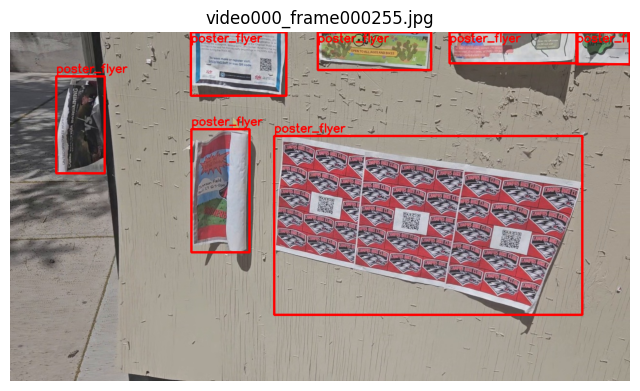

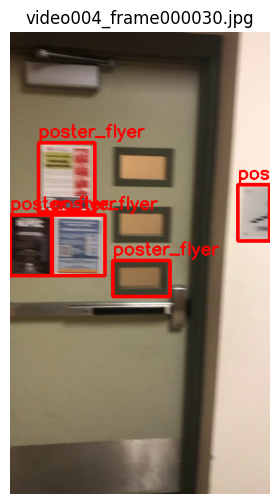

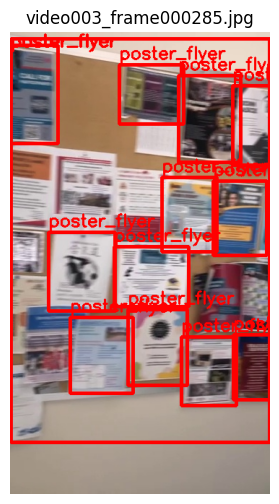

In [9]:
# Cell 9 — Preview a few pseudo-labels
import json
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


def draw_rcnn_annotations(image_path, record):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for box in record['boxes']:
        x1, y1, x2, y2 = [int(round(v)) for v in box]
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(img, CLASS_NAME, (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    return img


records = json.loads((OUTPUT_DIR / 'annotations' / 'train.json').read_text())
assert records, 'No train annotations found.'

for record in random.sample(records, k=min(3, len(records))):
    image_path = OUTPUT_DIR / 'images' / 'train' / record['image']
    img = draw_rcnn_annotations(image_path, record)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(record['image'])
    plt.show()


In [10]:
# Cell 10 — Train / fine-tune Faster R-CNN
import json
import math
import time
import torch
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


class PosterFlyerDataset(Dataset):
    def __init__(self, root, split):
        self.root = Path(root)
        self.split = split
        self.image_dir = self.root / 'images' / split
        self.records = json.loads((self.root / 'annotations' / f'{split}.json').read_text())

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        image_path = self.image_dir / record['image']
        image = Image.open(image_path).convert('RGB')
        image_np = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)
        boxes = torch.as_tensor(record['boxes'], dtype=torch.float32)
        labels = torch.as_tensor(record['labels'], dtype=torch.int64)
        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx]),
            'area': area,
            'iscrowd': iscrowd,
        }
        return image_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


def build_faster_rcnn_model(num_classes=2, pretrained=True):
    try:
        from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
        weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT if pretrained else None
        model = fasterrcnn_resnet50_fpn(weights=weights, weights_backbone=None)
    except TypeError:
        model = fasterrcnn_resnet50_fpn(pretrained=pretrained)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def move_targets_to_device(targets, device):
    moved = []
    for target in targets:
        moved.append({key: value.to(device) for key, value in target.items()})
    return moved


def evaluate_loss(model, loader, device):
    model.train()
    losses = []
    with torch.no_grad():
        for images, targets in loader:
            images = [image.to(device) for image in images]
            targets = move_targets_to_device(targets, device)
            loss_dict = model(images, targets)
            loss = sum(value for value in loss_dict.values())
            losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else float('inf')


train_dataset = PosterFlyerDataset(OUTPUT_DIR, 'train')
val_dataset = PosterFlyerDataset(OUTPUT_DIR, 'val')
assert len(train_dataset) > 0, 'No training records found.'

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True, num_workers=WORKERS, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH, shuffle=False, num_workers=WORKERS, collate_fn=collate_fn) if len(val_dataset) > 0 else None

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training Faster R-CNN on', device)

model = build_faster_rcnn_model(num_classes=2, pretrained=True).to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(EPOCHS // 3, 1), gamma=0.1)

run_dir = Path(PROJECT) / RUN_NAME
weights_dir = run_dir / 'weights'
weights_dir.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = weights_dir / 'best.pt'
LAST_MODEL_PATH = weights_dir / 'last.pt'
best_val_loss = float('inf')
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    start_time = time.time()

    for images, targets in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}'):
        images = [image.to(device) for image in images]
        targets = move_targets_to_device(targets, device)
        loss_dict = model(images, targets)
        loss = sum(value for value in loss_dict.values())

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        train_losses.append(float(loss.item()))

    scheduler.step()
    train_loss = float(np.mean(train_losses)) if train_losses else float('nan')
    val_loss = evaluate_loss(model, val_loader, device) if val_loader is not None else train_loss
    elapsed = time.time() - start_time

    row = {'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'seconds': elapsed}
    history.append(row)
    print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | seconds={elapsed:.1f}")

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'class_names': {0: 'background', 1: CLASS_NAME},
        'num_classes': 2,
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'img_size': IMG_SIZE,
        'model_name': 'fasterrcnn_resnet50_fpn',
    }
    torch.save(checkpoint, LAST_MODEL_PATH)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(checkpoint, BEST_MODEL_PATH)
        print('Saved new best model:', BEST_MODEL_PATH)

history_path = run_dir / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

print('Best model:', BEST_MODEL_PATH)


Training Faster R-CNN on cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 105MB/s]


Epoch 1/25:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 001 | train_loss=1.2317 | val_loss=1.0542 | seconds=3.8
Saved new best model: /content/runs_faster_rcnn/poster_flyer_finetune/weights/best.pt


Epoch 2/25:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoch 023 | train_loss=0.1098 | val_loss=0.3445 | seconds=3.1


Epoch 24/25:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 024 | train_loss=0.1044 | val_loss=0.3534 | seconds=3.3


Epoch 25/25:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 025 | train_loss=0.1043 | val_loss=0.3492 | seconds=3.3
Best model: /content/runs_faster_rcnn/poster_flyer_finetune/weights/best.pt


In [11]:
# Cell 11 — Validate best Faster R-CNN model
import torch
import numpy as np
from pathlib import Path

assert BEST_MODEL_PATH.exists(), f'Missing best model: {BEST_MODEL_PATH}'

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model = build_faster_rcnn_model(num_classes=checkpoint.get('num_classes', 2), pretrained=False).to(device)
model.load_state_dict(checkpoint['model_state_dict'])

if val_loader is not None:
    val_loss = evaluate_loss(model, val_loader, device)
    print('Best checkpoint epoch:', checkpoint.get('epoch'))
    print('Stored validation loss:', checkpoint.get('val_loss'))
    print('Recomputed validation loss:', val_loss)
else:
    print('No validation records found.')


Best checkpoint epoch: 15
Stored validation loss: 0.32502090036869047
Recomputed validation loss: 2.3543189764022827


In [12]:
# Cell 12 — Run inference on test images
import cv2
import torch
import numpy as np
from pathlib import Path
from PIL import Image

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
best_model = build_faster_rcnn_model(num_classes=checkpoint.get('num_classes', 2), pretrained=False).to(device)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

test_source = OUTPUT_DIR / 'images' / 'test'
if not any(test_source.glob('*.jpg')):
    test_source = OUTPUT_DIR / 'images' / 'val'

pred_dir = Path(PROJECT) / (RUN_NAME + '_predictions')
pred_dir.mkdir(parents=True, exist_ok=True)

image_paths = sorted(test_source.glob('*.jpg'))
assert image_paths, f'No test or val images found under {test_source}'

with torch.inference_mode():
    for image_path in image_paths:
        image = Image.open(image_path).convert('RGB')
        image_np = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).to(device)
        output = best_model([image_tensor])[0]

        draw = cv2.cvtColor((image_np * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        boxes = output['boxes'].detach().cpu().numpy()
        scores = output['scores'].detach().cpu().numpy()
        labels = output['labels'].detach().cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            if score < INFER_CONF or int(label) != 1:
                continue
            x1, y1, x2, y2 = [int(round(v)) for v in box]
            cv2.rectangle(draw, (x1, y1), (x2, y2), (0, 0, 255), 3)
            cv2.putText(draw, f'{CLASS_NAME} {score:.2f}', (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

        cv2.imwrite(str(pred_dir / image_path.name), draw)

print('Predictions saved under:', pred_dir)


Predictions saved under: /content/runs_faster_rcnn/poster_flyer_finetune_predictions


In [13]:
# Cell 13 — Zip dataset and best model for download
from pathlib import Path
from google.colab import files
import zipfile

zip_path = Path('/content/poster_flyer_rcnn_outputs.zip')
if zip_path.exists():
    zip_path.unlink()

best_model_path = Path('/content/runs_faster_rcnn/poster_flyer_finetune/weights/best.pt')
assert best_model_path.exists(), f'Missing best model: {best_model_path}'

with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for path in OUTPUT_DIR.rglob('*'):
        if path.is_file():
            zf.write(path, arcname=path.relative_to('/content'))
    zf.write(best_model_path, arcname=best_model_path.relative_to('/content'))
    pred_dir = Path(PROJECT) / (RUN_NAME + '_predictions')
    if pred_dir.exists():
        for path in pred_dir.rglob('*'):
            if path.is_file():
                zf.write(path, arcname=path.relative_to('/content'))

print('Created:', zip_path)
print('Included best model:', best_model_path)
files.download(str(zip_path))


Created: /content/poster_flyer_rcnn_outputs.zip
Included best model: /content/runs_faster_rcnn/poster_flyer_finetune/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>